In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os
import scanpy as sc
import scvi
import seaborn as sns



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load Data

In [3]:
# Save dataframe 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_with_RNA_cluster_and_DNAdebrisflag.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris
atac_bc,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO


In [4]:
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
h5_rna_union_file = os.path.join(Union_cell_subdir, 'Union_3set_rna.h5ad')

h5_rna_union = sc.read_h5ad(h5_rna_union_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
h5_rna_union, h5_rna_union.shape

(AnnData object with n_obs × n_vars = 2381 × 36601
     obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'gene_ids', 'feature_types', 'genome',
 (2381, 36601))

In [7]:
sc.pp.filter_genes(h5_rna_union, min_counts=3)
h5_rna_union.raw = h5_rna_union # keep full dimension safe
h5_rna_union.layers['counts'] = h5_rna_union.X
sc.pp.highly_variable_genes(
h5_rna_union    ,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [8]:
SCVI_LATENT_KEY = "RNA_scVI_unionBC"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_unionBC"


vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna_union)
h5_rna_union.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna_union, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_union, min_dist=0.3)
sc.tl.leiden(h5_rna_union, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

INFO     File /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_unioncells_RNA_scvi_model/model.pt      
         already downloaded                                                                                        


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

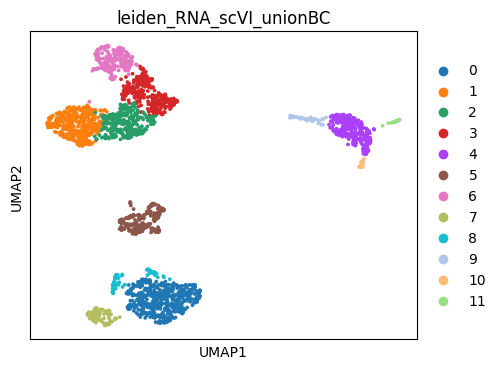

In [ ]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['leiden_RNA_scVI_unionBC'], wspace=0.2, size=30, ncols=3)

In [16]:
col_list = ['total_fragments', 'atac_pass_CR', 'atac_pass_entropy',
       'atac_pass_archr_TSS', '_2set_identified_by_atac_SC',
       '_2set_identified_by_atac_ST', 'rna_barcodes', 'rna_pass_CR', 'Entropy', 'DNA_debris']
for col in col_list:
    h5_rna_union.obs[col] = h5_rna_union.obs['atac_barcodes'].map(union_cell_info[col])

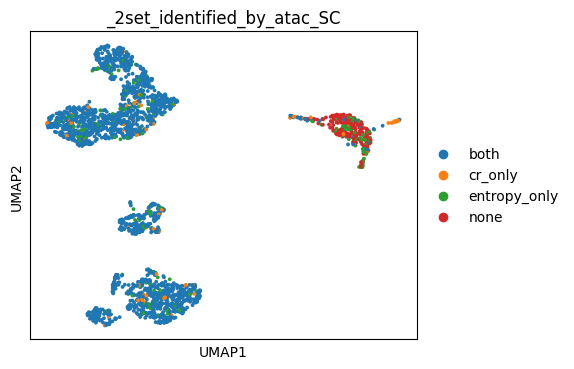

In [18]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_union, color=['_2set_identified_by_atac_SC'], wspace=0.2, size=30, ncols=3)

# Now only subset BCs for comparing SADE/entropy vs CellRanger

In [20]:
h5_rna_SC = h5_rna_union[h5_rna_union.obs['_2set_identified_by_atac_SC'] != 'none'].copy()


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [21]:
sc.pp.filter_genes(h5_rna_SC, min_counts=3)
h5_rna_SC.raw = h5_rna_SC # keep full dimension safe
h5_rna_SC.layers['counts'] = h5_rna_SC.X
sc.pp.highly_variable_genes(
h5_rna_SC,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [ ]:
SCVI_LATENT_KEY = "RNA_scVI_cmpSC"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_cmpSC"


scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna_SC, layer="counts")
vae = scvi.model.SCVI(h5_rna_SC, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

h5_rna_SC.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_cmpSC_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)

# clustering using scVI latent representation via Leiden
resolution = 0.5
sc.pp.neighbors(h5_rna_SC, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna_SC, min_dist=0.5)
sc.tl.leiden(h5_rna_SC, key_added=SCVI_CLUSTERS_KEY, resolution=resolution )

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers whi

Epoch 400/400: 100%|██████████| 400/400 [01:32<00:00,  8.46it/s, v_num=1, train_loss_step=5.87e+3, train_loss_epoch=5.26e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:32<00:00,  4.31it/s, v_num=1, train_loss_step=5.87e+3, train_loss_epoch=5.26e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



In [45]:
h5_rna_SC.obs['log_n_genes_by_RNA'] = np.log10(h5_rna_SC.obs['n_genes_by_RNA_counts'] )
h5_rna_SC.obs['log_total_frag'] = np.log10(h5_rna_SC.obs['total_fragments'] )

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


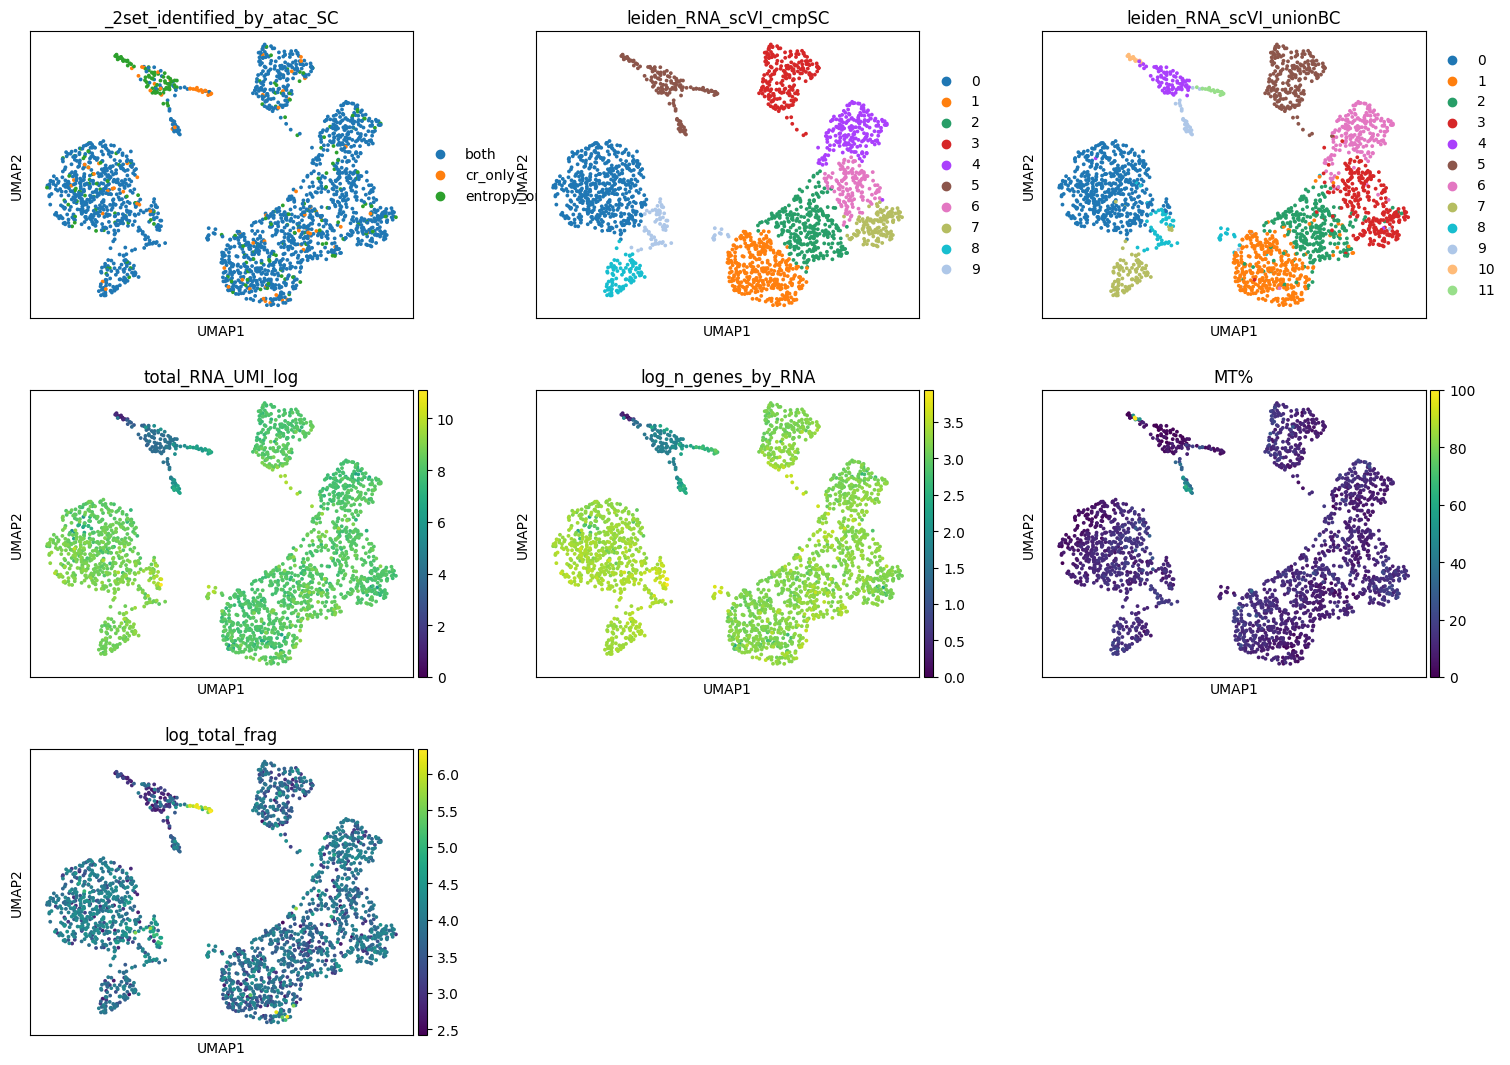

In [47]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna_SC, color=['_2set_identified_by_atac_SC', 'leiden_RNA_scVI_cmpSC']+ 
               ['leiden_RNA_scVI_unionBC']+ 
               ['total_RNA_UMI_log', 'log_n_genes_by_RNA',  'MT%','log_total_frag'], wspace=0.2, size=30, ncols=3)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1760: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


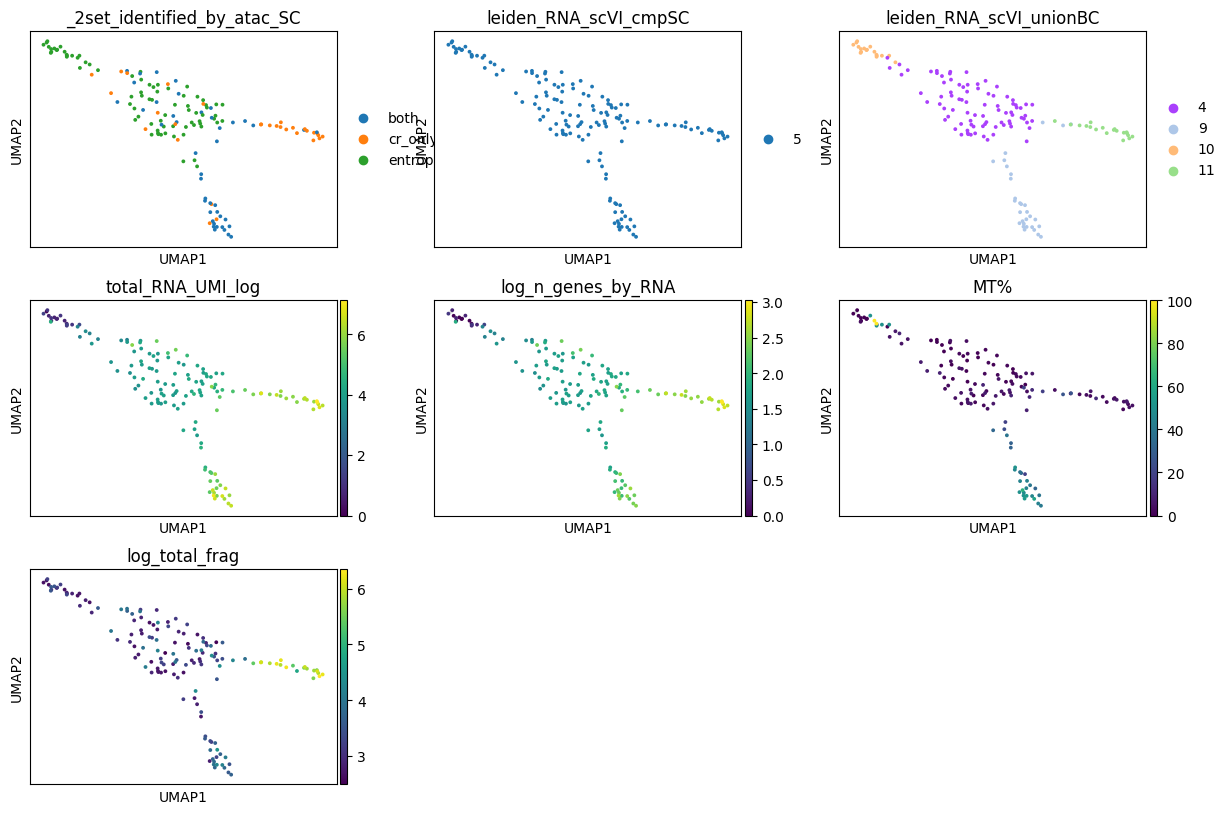

In [49]:
RNAc5_h5_SC = h5_rna_SC[h5_rna_SC.obs['leiden_RNA_scVI_cmpSC'] == '5'].copy()

with plt.rc_context({'figure.figsize': (4, 3)}):
    sc.pl.umap(RNAc5_h5_SC, color=['_2set_identified_by_atac_SC', 'leiden_RNA_scVI_cmpSC']+ 
               ['leiden_RNA_scVI_unionBC']+ 
               ['total_RNA_UMI_log', 'log_n_genes_by_RNA',  'MT%','log_total_frag'], wspace=0.2, size=30, ncols=3)

# only analyzing c5 

In [54]:
RNAc5_h5_SC

AnnData object with n_obs × n_vars = 151 × 21791
    obs: 'rna_barcodes', 'atac_barcodes', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%', '_scvi_batch', '_scvi_labels', 'leiden_RNA_scVI_unionBC', 'total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'rna_pass_CR', 'Entropy', 'DNA_debris', 'leiden_RNA_scVI_cmpSC', 'log_n_genes_by_RNA', 'log_total_frag', 'leiden_RNA_scVI_cmpSC_c5subset'
    var: 'gene_ids', 'feature_types', 'genome', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden_RNA_scVI_unionBC', 'leiden_RNA_scVI_unionBC_colors', '_2set_identified_by_atac_SC_colors', 'leiden_RNA_scVI_cmpSC', 'leiden_RNA_scVI_cmpSC_colors', 'leiden_RNA_scVI_cmpSC_c5subset', 'leiden_RNA_scVI_cmpSC_c5subset_colors'
    obsm: 'RNA_scVI_unionBC', 'X_umap', 'R

In [58]:
SCVI_LATENT_KEY = "RNA_scVI_cmpSC_c5subset"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI_cmpSC_c5subset"


scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(RNAc5_h5_SC, layer="counts")
vae = scvi.model.SCVI(RNAc5_h5_SC, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

RNAc5_h5_SC.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

# clustering using scVI latent representation via Leiden
resolution = 0.5
sc.pp.neighbors(RNAc5_h5_SC, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(RNAc5_h5_SC, min_dist=0.5)
sc.tl.leiden(RNAc5_h5_SC, key_added=SCVI_CLUSTERS_KEY, resolution=resolution -0.1 )

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=10). Set

Epoch 400/400: 100%|██████████| 400/400 [00:13<00:00, 28.12it/s, v_num=1, train_loss_step=558, train_loss_epoch=354]  

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [00:13<00:00, 29.55it/s, v_num=1, train_loss_step=558, train_loss_epoch=354]


In [59]:
# clustering using scVI latent representation via Leiden
resolution = 0.5
sc.pp.neighbors(RNAc5_h5_SC, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(RNAc5_h5_SC, min_dist=0.5)
sc.tl.leiden(RNAc5_h5_SC, key_added=SCVI_CLUSTERS_KEY, resolution=resolution -0.1 )

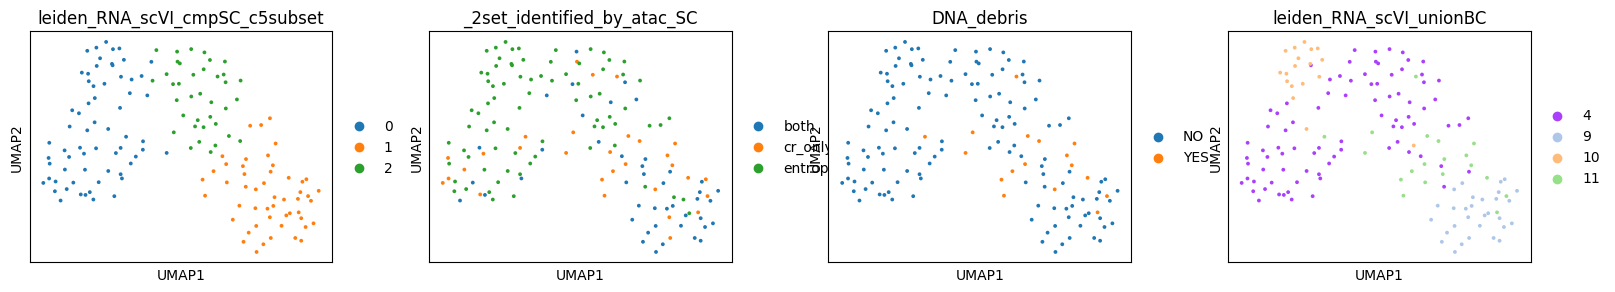

In [60]:
with plt.rc_context({'figure.figsize': (4, 3)}):
    sc.pl.umap(RNAc5_h5_SC, color=['leiden_RNA_scVI_cmpSC_c5subset', '_2set_identified_by_atac_SC', 'DNA_debris', 'leiden_RNA_scVI_unionBC'], wspace=0.2, size=30, ncols=4)